In [3]:
# Math modules
import pandas as pd
import numpy as np

# Neural networt modules for creating RNN
import torch
import torch.nn as nn

# Plotting modules
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [4]:
# Gathering dataset
dataset = pd.read_csv("malicious_phish.csv")
print(dataset)
dataset["type"].value_counts()

                                                      url        type
0                                        br-icloud.com.br    phishing
1                     mp3raid.com/music/krizz_kaliko.html      benign
2                         bopsecrets.org/rexroth/cr/1.htm      benign
3       http://www.garage-pirenne.be/index.php?option=...  defacement
4       http://adventure-nicaragua.net/index.php?optio...  defacement
...                                                   ...         ...
651186            xbox360.ign.com/objects/850/850402.html    phishing
651187       games.teamxbox.com/xbox-360/1860/Dead-Space/    phishing
651188         www.gamespot.com/xbox360/action/deadspace/    phishing
651189      en.wikipedia.org/wiki/Dead_Space_(video_game)    phishing
651190          www.angelfire.com/goth/devilmaycrytonite/    phishing

[651191 rows x 2 columns]


type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

In [5]:
# Making all links lowercased
def lowercaseURLs(urlCol):
    return urlCol.str.lower()

dataset["lowercase_url"] = lowercaseURLs(dataset["url"])
dataset

,url,type,lowercase_url
0,br-icloud.com.br,phishing,br-icloud.com.br
1,mp3raid.com/music/krizz_kaliko.html,benign,mp3raid.com/music/krizz_kaliko.html
2,bopsecrets.org/rexroth/cr/1.htm,benign,bopsecrets.org/rexroth/cr/1.htm
3,http://www.garage-pirenne.be/index.php?option=...,defacement,http://www.garage-pirenne.be/index.php?option=...
4,http://adventure-nicaragua.net/index.php?optio...,defacement,http://adventure-nicaragua.net/index.php?optio...
...,...,...,...
651186,xbox360.ign.com/objects/850/850402.html,phishing,xbox360.ign.com/objects/850/850402.html
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing,games.teamxbox.com/xbox-360/1860/dead-space/
651188,www.gamespot.com/xbox360/action/deadspace/,phishing,www.gamespot.com/xbox360/action/deadspace/
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing,en.wikipedia.org/wiki/dead_space_(video_game)


In [6]:
# Counting the number of unique characters and categories throughout the whole data set
allChars = set(''.join(dataset["lowercase_url"]))
allCategories = list(dataset["type"].unique())
n_chars = len(allChars)
n_categories = len(allCategories)

charToIndex = {c: i for i, c in enumerate(allChars)}
indexToChar = {i: c for c, i in enumerate(allChars)}

print(allChars)
print(allCategories)
print(n_chars, "characters total")
print(n_categories, "categories total")

{'f', '\r', '\x91', 'ป', '/', 'ซ', '\x99', '\x0b', '\x8e', '|', '¨', '5', '\x97', '\x1d', '\x02', '\x8f', 'น', '6', 'ฺ', '\x1f', 'ต', '¶', '&', 'd', '7', '\x1b', 'â', '\x9a', 'ฏ', '\x08', '\x85', '+', 'þ', '0', 'z', '\x16', '8', ',', 'x', '€', '=', 'ิ', 'g', 'º', 'ึ', '\x87', 'š', '\x96', '\x0e', '\x89', 'ฦ', 'ฝ', '3', 'ย', 'ฐ', 'ู', '•', '2', '4', 'ำ', 'ุ', '\uf1dc', '¥', '\x03', 'ˆ', '§', 'ื', '¤', '\n', '\x19', 'ã', 'ฃ', '™', '\\', '\x11', 'v', 'ก', 'ฎ', '\x7f', '\x13', 'w', '‚', 'æ', 'à', 'ร', '`', '่', '\x94', 'ò', '¼', '$', 'ฬ', 'o', 'ธ', '¿', '–', '\x14', 'n', 'ö', '\x1e', '\x07', 'i', 'า', ' ', '\xa0', 'อ', '\x81', '\x88', 'ด', 'ห', '\t', '×', '\x8d', '(', '©', '\x8b', 'ไ', 'ø', '\x9c', 'เ', '!', ';', '\x0f', '\x98', 'ญ', 'ฅ', '_', '\x84', '¬', 'è', 'ฑ', '\x05', '¡', 'ë', 'k', 'ú', '9', 'ï', '\x04', 'ง', 'ñ', 'j', '拠', '·', 'ù', 'ถ', '\x8a', '\x0c', 'ฤ', 'a', '\x1a', 'r', 'ƒ', '÷', '±', '\x83', '^', '½', 'h', 'จ', '¸', '{', 'û', '*', '¢', 'ì', 'm', '°', '.', '\xad', 'ฟ', '%', '

In [7]:
# Defining the recurrent neural network (may differ from Assignment 4's RNN)
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        
        self.rnn_cell = nn.RNNCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, x):
        """
        x: size [seq_length, 1, input_size]
        """
        h = torch.zeros(x.size(1), self.hidden_size)
        
        for i in range(x.size(0)):
            h = self.rnn_cell(x[i], h)
        
        out = self.softmax(self.fc(h))
        return out

In [32]:
import time
import math
import random
random.seed(0)

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {int(s)}s'

# Convert letter to index for faster lookup
def letterToIndex(letter):
    return charToIndex[letter]

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_chars)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] += 1
    return tensor

# Make category into tensor
def categoryToTensor(category):
    li = allCategories.index(category)
    tensor = torch.tensor([li], dtype=torch.long)
    return tensor

# To interpret the output of the network, use Tensor.topk to get the index of the greatest value
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return list(allCategories)[category_i], category_i

In [ ]:
# Iteratively training RNN model

import pickle

def train(model, n_iters = 100000, print_every = 1000, plot_every = 500, learning_rate = 0.005):

    # Counts the number of true positives, false positives, true negatives, and false negatives

    tp = 0  # True positives are counted when the model correctly predicts a malicious (or non-benign) URL
    fp = 0  # False positives are counted when the model incorrectly predicts a benign URL as malicious
    tn = 0  # True negatives are counted when the model correctly predicts a benign URL
    fn = 0  # False negatives are counted when the model incorrectly predicts a malicious URL as benign

    # Evaluation metrics
    accuracy, precision, recall, false_positive_rate, f1_score = 0, 0, 0, 0, 0

    # Turn on the training model
    model.train()
    
    # Loss and optimizer
    criterion = nn.NLLLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    running_loss = 0
    all_losses = []
    all_acc = []
    all_prec = []
    all_rec = []
    all_fpr = []
    all_f1 = []
    
    # Train loop
    start = time.time()
    for i in range(n_iters):
        # Sample a randmon row from the dataset
        currSample = dataset.iloc[random.randint(0, len(dataset) - 1)]

        # Get input and target tensors from the sample
        x = currSample["lowercase_url"]
        y = currSample["type"]
        x_tensor = lineToTensor(x)
        y_tensor = categoryToTensor(y)
        
        # Zero gradient
        optimizer.zero_grad()
        
        # Forward pass
        output = model(x_tensor)
        loss = criterion(output, y_tensor)
        
        # Backprop and update
        loss.backward()
        optimizer.step()
        
        # Record loss
        running_loss += loss.item()
        
        # Get guess from output and compute metrics
        isBenign = (y == "benign")
        guess, guess_i = categoryFromOutput(output)
        guessBenign = (guess == "benign")

        # Confusion matrix updated for binary classification
        if isBenign and guessBenign:
            tn += 1
        elif isBenign and not guessBenign:
            fn += 1
        elif not isBenign and guessBenign:
            fp += 1
        else:  # not isBenign and not guessBenign
            tp += 1
        
        # Print iter, loss, name, and guess; also update confusion matrix metrics
        if i % print_every == 0 and i > 0:
            correct = '✓' if guess == y else '✗ (%s)' % y
            print('%d %d%% (%s) %.4f %s / %s %s' % (i, i / n_iters * 100, timeSince(start), loss, x, guess, correct))
        
        # Append loss and metrics for plotting
        if i % plot_every == 0 and i > 0:

            all_losses.append(running_loss / plot_every)
            accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            all_acc.append(accuracy)
            all_prec.append(precision)
            all_rec.append(recall)
            all_fpr.append(false_positive_rate)
            all_f1.append(f1_score)
            running_loss = 0
    
    print()
    
    print(f"100% Training Complete! Ran on {n_iters} random samples with replacement.")
    print('Final Evaluation Metrics on Training Set:')
    print(f'Accuracy: {100 * accuracy:.2f}%')
    print(f'Precision: {100 * precision:.2f}%')
    print(f'Recall: {100 * recall:.2f}%')
    print(f'False Positive Rate: {100 * false_positive_rate:.2f}%')
    print(f'F1 Score: {100 * f1_score:.2f}%')
    print()

    # Print confusion matrix
    print("Confusion Matrix:")
    print(f"TP: {tp}, FP: {fp}")
    print(f"FN: {fn}, TN: {tn}")

    # Plot for losses and metrics
    plt.figure()
    plt.plot(all_losses)
    plt.xlabel('Iterations (every %d)' % plot_every)
    plt.ylabel('Loss')
    plt.title('Training Loss over Time')
    plt.show()

    plt.figure()
    plt.plot(all_acc)
    plt.plot(all_prec)
    plt.plot(all_rec)
    plt.plot(all_fpr)
    plt.plot(all_f1)
    plt.xlabel('Iterations (in hundreds)')
    plt.ylabel('Metrics')
    plt.title('Evaluation Metrics over Time')
    plt.legend(['Accuracy', 'Precision', 'Recall', 'False Positive Rate', 'F1 Score'])
    plt.show()

    # Save results in a pickle file
    results = {
        'losses': all_losses,
        'accuracy': all_acc,
        'precision': all_prec,
        'recall': all_rec,
        'false_positive_rate': all_fpr,
        'f1_score': all_f1
    }

    with open('training_results.pkl', 'wb') as f:
        pickle.dump(results, f)

1000 1% (0m 31s) 1.6945 http://www.productiva.com.br/index.php?option=com_mailto&tmpl=component&link=ahr0cdovl3d3dy5wcm9kdwn0axzhlmnvbs5ici9pbmrlec5waha%2fb3b0aw9upwnvbv9jb250zw50jnzpzxc9yxj0awnszszpzd0xmdmlm0fvympldgl2b3mtzgutdw0tzgf0ys13yxjlag91c2umy2f0awq9ndmlm0fwcm9kdwn0axzhjkl0zw1pzd0xntu= / benign ✗ (defacement)
2000 2% (1m 5s) 2.0275 commbank.com.au.suehadow.co.uk / benign ✗ (phishing)
3000 3% (1m 32s) 2.8367 http://3cf.ru/2015/07/21/eksperty-proveriat-realnost-pokazanii-glavnogo-figyranta-dela-nemcova/ / benign ✗ (malware)
4000 4% (2m 31s) 0.3172 citymelt.com/county/new-jersey/morris+county-nj.html / benign ✓
5000 5% (3m 24s) 1.9710 tools.ietf.org/html/rfc568 / benign ✗ (phishing)
6000 6% (4m 10s) 0.1342 backtothefuture.wikia.com/wiki/marty_mcfly / benign ✓
7000 7% (4m 44s) 0.1541 youtube.com/watch?v=x2_xj_rgoso / benign ✓
8000 8% (5m 29s) 0.2725 mcgillultimate.ca/?q=womens / benign ✓
9000 9% (6m 47s) 1.7694 oreilly.com/catalog/9780596003234/ / benign ✗ (phishing)
10000 10% (7m

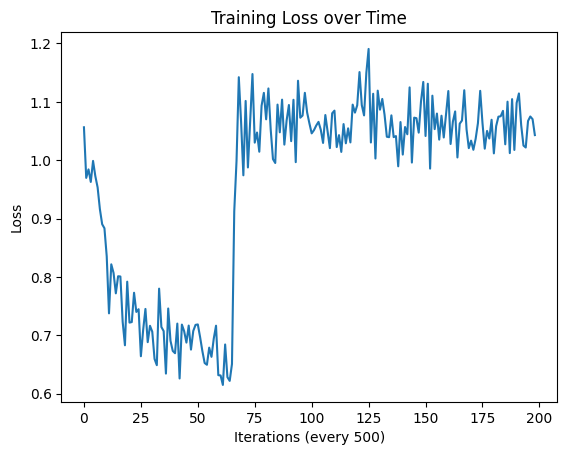

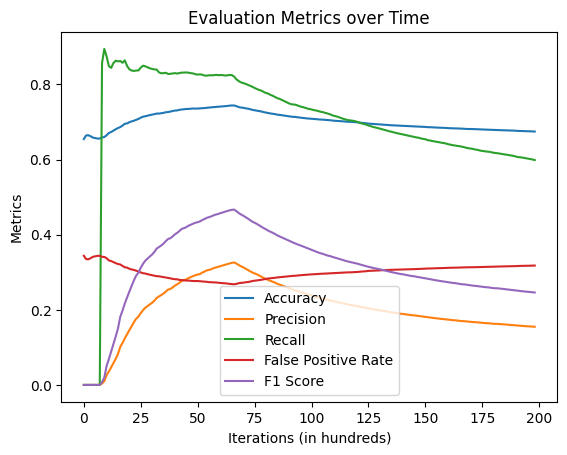

In [34]:
# Evaluate the RNN model

# Random seed for reproducibility 
# ! DO NOT CHANGE THESE LINES !
import random
torch.manual_seed(0)
random.seed(0)

n_hidden = 128
rnn = RNN(n_chars, n_hidden, n_categories)

#  ! (WARNING: This will take approximately an hour to run if you are using n_iters=100000)
train(rnn)